# 14_损失函数-Huber损失

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊损失函数中的 Huber 损失\~

先来简单回顾一下，什么是损失函数\~

机器学习中，**损失函数**是用来衡量“预测结果”和“真实结果”之间差距的一个公式。

可以理解为：**你猜得越准，损失函数的值就越小；猜得越离谱，损失函数的值就越大。**

#### 那么，Huber 损失函数是干嘛的？

Huber 损失是一种 **折中的损失函数**，结合了 **均方误差（MSE）** 和 **绝对误差（MAE）** 的优点：

| 损失函数 | 特点 |
|-|-|
| MSE（平方误差） | 对异常值敏感（因为误差平方，会放大大误差） |
| MAE（绝对误差） | 对异常值鲁棒，但不可导、不稳定 |
| Huber 损失 | 小误差时像 MSE， 大误差时像 MAE，是一种「软切换」的混合策略 |

关于**均方误差（MSE）** 和 **绝对误差（MAE）**，大家可以从其他几个章节学习\~

### Huber 损失

> “希望当预测差得不太多的时候，用 MSE 来优化模型（因为平方误差平滑、可导）；  
> 但当预测特别离谱的时候，就不要用平方了，改用绝对误差（不然异常值会拖垮模型）。”

这就像：**小错归平方，大错用绝对值。**

所以 Huber 损失就是一个“分段函数”：

- 误差小的时候，使用平方误差；
- 误差大的时候，使用线性增长的绝对误差。

### Huber 损失数学定义

我们假设：

- 预测值是 $\hat{y}$；
- 实际值是 $y$；
- 误差是 $e = y - \hat{y}$；
- $\delta$ 是人为设置的“分界点”（容忍误差的阈值，超出这个就认为是异常）；

**Huber 损失函数的定义为：**


$$
L_{\delta}(e) =\begin{cases}\frac{1}{2} e^2, & \text{if } |e| \leq \delta \\\delta (|e| - \frac{1}{2}\delta), & \text{if } |e| > \delta\end{cases}
$$


- 如果预测误差很小，就用 $\frac{1}{2}e^2$，和 MSE 一样；
- 如果预测误差很大，就用线性的形式 $\delta (|e| - \frac{1}{2}\delta)$，更像 MAE。

这个函数在 $e = \pm\delta$ 的位置处是连续、可导的，这是 Huber 函数比 MAE 更容易优化的关键。

我们来推导这个分段函数为什么这么设计。

#### 1）平方误差的性质：

平方误差函数是：$L = \frac{1}{2} e^2$

- 优点：连续、可导；
- 缺点：对大误差（outliers）太敏感，比如 10 的平方是 100，会导致模型过度拟合异常值。

#### 2）绝对误差的性质：

绝对误差函数是：$L = |e|$

- 优点：对大误差更鲁棒；
- 缺点：在 $e=0$ 的位置不可导，不利于梯度下降优化。

#### 3）目标：

Huber 的目标是兼顾两者的优点：

- 小误差区域使用平滑的 MSE；
- 大误差区域使用鲁棒的 MAE。

因此分段定义如下：

- 当 $|e| \le \delta$，用平方误差 $\frac{1}{2}e^2$；
- 当 $|e| > \delta$，设计一个与 $\frac{1}{2}e^2$ 在边界平滑衔接的线性函数。

#### 4）推导右半边（线性区域）的函数表达式

我们要求两个条件：

- 在 $|e| = \delta$ 处 **函数值要相等**；
- 在 $|e| = \delta$ 处 **导数要相等**（保持光滑）。

设线性部分为：


$$
L(e) = a |e| + b
$$


我们对比函数值和导数：

- 函数值匹配：


$$
\frac{1}{2} \delta^2 = a \delta + b\Rightarrow b = \frac{1}{2} \delta^2 - a \delta
$$


- 导数匹配（平方部分导数是 $\delta$，线性部分导数是 $a$）：$a = \delta$代入得：$b = \frac{1}{2} \delta^2 - \delta^2 = -\frac{1}{2}\delta^2$所以线性部分是：$L(e) = \delta |e| - \frac{1}{2} \delta^2$

这就是我们之前写的 Huber 损失的线性段。

### Huber 损失算法流程（用于训练模型）

1. **输入**：

   - 一组训练数据 $(x\_i, y\_i)$；
   - 模型的预测函数 $\hat{y}\_i = f(x\_i, \theta)$；
   - 误差阈值 $\delta$；
   - 初始参数 $\theta$；
2. **计算每个样本的预测误差**：


$$
e_i = y_i - \hat{y}_i
$$


1. **使用 Huber 损失函数计算每个样本的损失**：


$$
L_i =\begin{cases}\frac{1}{2} e_i^2, & |e_i| \le \delta \\\delta(|e_i| - \frac{1}{2}\delta), & |e_i| > \delta\end{cases}
$$


1. **求损失函数总和**（加权平均或者总和）作为目标：


$$
\mathcal{L} = \frac{1}{n} \sum_{i=1}^n L_i
$$


1. **计算损失函数关于模型参数的梯度**；
2. **使用梯度下降法更新参数** $\theta$；
3. **循环迭代，直到损失收敛或满足迭代条件。**

### 一个简单例子

假设我们预测房价：

- 实际值 $y = 100$
- 预测值 $\hat{y} = 95$
- 那么误差 $e = 5$

如果 $\delta = 3$，因为 $|e| = 5 > \delta$，属于大误差区域。

此时 Huber 损失是：


$$
L = \delta(|e| - \frac{1}{2} \delta) = 3(5 - \frac{3}{2}) = 3 \cdot 3.5 = 10.5
$$


如果误差 $e = 2$，小于 $\delta$：


$$
L = \frac{1}{2} \cdot 2^2 = 2.0
$$


说明：**对小误差，Huber 更宽容；对大误差，Huber 不会像 MSE 那样一飞冲天。**

## 完整案例

这里，给出一个完整的关于Huber损失的案例：

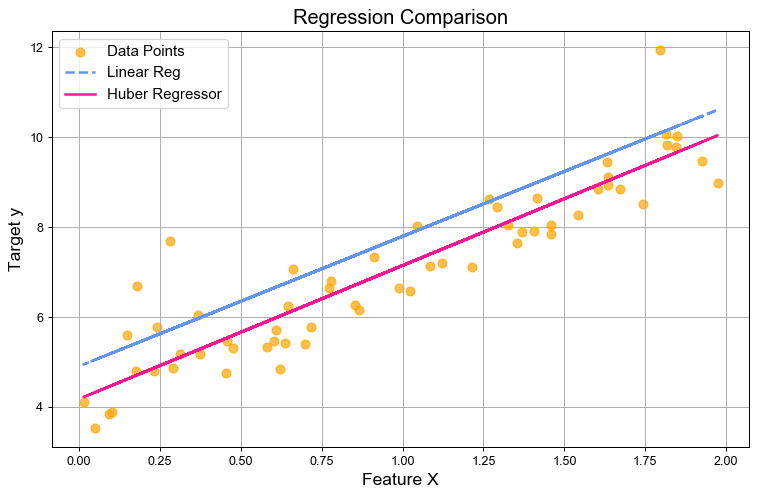

Linear Regression: MSE = 1.01, MAE = 0.88
Huber Regressor:    MSE = 0.56, MAE = 0.55


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# 1. 合成数据
np.random.seed(42)
X = 2 * np.random.rand(200, 1)
y_true = 4 + 3 * X.flatten() + np.random.randn(200) * 0.5

# 添加异常点
n_outliers = 20
indices = np.random.choice(np.arange(200), n_outliers, replace=False)
y_true[indices] += np.random.rand(n_outliers) * 15  # 大偏差

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.3, random_state=42)

# 3. 训练模型：Huber 回归 vs 普通线性回归
huber = HuberRegressor(epsilon=1.35, alpha=0.0).fit(X_train, y_train)
linear = LinearRegression().fit(X_train, y_train)

# 4. 模型预测
y_pred_huber = huber.predict(X_test)
y_pred_linear = linear.predict(X_test)

# 5. 评估指标
mse_huber = mean_squared_error(y_test, y_pred_huber)
mae_huber = mean_absolute_error(y_test, y_pred_huber)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

# 可视化对比
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Data Points', s=50, alpha=0.7, color='orange')
plt.plot(X_test, y_pred_linear, label='Linear Reg', linewidth=2, linestyle='--', color='cornflowerblue')
plt.plot(X_test, y_pred_huber, label='Huber Regressor', linewidth=2, color='deeppink')
plt.title('Regression Comparison', fontsize=16)
plt.xlabel('Feature X', fontsize=14)
plt.ylabel('Target y', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 打印评估结果
print("Linear Regression: MSE = {:.2f}, MAE = {:.2f}".format(mse_linear, mae_linear))
print("Huber Regressor:    MSE = {:.2f}, MAE = {:.2f}".format(mse_huber, mae_huber))

![原文参考图，当前结果见代码输出](attachments/img_016.png)

**1. 生成带异常值的合成数据**

- 设置随机种子 `np.random.seed(42)` 保证可复现。
- 用 `X = 2 * np.random.rand(200, 1)` 生成 200 个 [0, 2) 区间的特征值。
- 构造线性真实模型 `y_true = 4 + 3 * X + noise`，其中 `noise` 服从标准正态分布并放大 0.5。
- 随机选择 20 个样本，向其目标值加入大偏差（0–15 之间随机扰动），以模拟真实世界中的异常值。

**2. 划分训练集和测试集**

- 使用 `train_test_split(..., test_size=0.3)` 将 200 个样本划分为 70% 训练和 30% 测试，保持数据分布一致。

**3. 训练模型**

- **普通线性回归**：`LinearRegression()`，对应最小二乘（MSE）损失。
- **Huber 回归**：`HuberRegressor(epsilon=1.35, alpha=0.0)`

  - `epsilon` 对应 Huber 损失中的 δ。
  - `alpha=0.0` 表示不使用正则化，仅对比损失函数本身效果。

**4. 模型预测与评估**

- 在测试集上分别调用 `.predict()`。
- 计算并打印两种模型的 MSE（均方误差）和 MAE（平均绝对误差）：

  - **普通线性回归**：MSE = 1.01，MAE = 0.88
  - **Huber 回归**：MSE = 0.56，MAE = 0.55  
  结果表明，在含有异常值的数据上，Huber 回归显著降低了两个指标。

**5. 可视化对比**

使用 Matplotlib 画出测试点（橙色散点）和两种回归直线：

- 线性回归（虚线）
- Huber 回归（实线）

## 算法分析

### Huber 损失函数优缺点

**优点**：

- **对异常值具有鲁棒性**：当误差 $|e| > \delta$ 时，Huber 损失线性增长，不会像 MSE 那样急剧放大大误差。
- **保持可导性**：相比 MAE 在 $e = 0$ 处不可导，Huber 在整个区间都是连续可导的，便于使用梯度下降等优化算法。
- **可调节性**：参数 $\delta$（`epsilon`）可通过交叉验证选取。当你对误差容忍度高时 $\delta$ 可设大，反之设小。

**缺点**：

- **需要手动设置** $\delta$：不同数据分布需要不同 $\delta$，参数调整成本较高；
- **对超大规模异常仍有影响**：异常值过多或过于离群时，线性区域依然会引入较大偏差；
- **收敛速度不一定优于 MSE**：在绝大多数误差小于 $\delta$ 的情况下，Huber 和 MSE 本质相同，若 $\delta$ 设置过大，效果退化为 MSE。

### 与相似算法对比

| 损失函数 | 对异常值敏感度 | 可导性 | 调参难度 | 适用场景 |
|-|-|-|-|-|
| MSE (L2) | 非常敏感（平方放大） | 完全可导 | 无 | 数据干净、异常值极少 |
| MAE (L1) | 低敏感（线性增长） | 在 0 点不可导 | 无 | 异常值多、需要绝对误差度量 |
| Huber Loss | 中等敏感 (分段线性) | 完全可导 | 需要选择 δ | 有少量异常值且需可导优化时 |
| Tukey Loss | 极低敏感 (重缩尾) | 不全可导 (截断处) | 高 | 异常值极多且需极强鲁棒性 |

### 优选 Huber Loss 的情况

1. 数据集中存在**少量**异常值，且希望算法对异常有一定容错，又不愿完全放弃可导优化。
2. 对训练速度有要求，希望梯度稳定便于收敛，但又需避免 MSE 对异常过度敏感带来的超调。
3. 实际场景中，观测值误差分布接近高斯但偶有离群点，比如金融收益预测、物理实验噪声校正等。

### 可以考虑其他算法的情况

1. **异常值极多** 或需极端鲁棒时，可选 Tukey 损失或 RANSAC 一类算法。
2. **数据几乎无异常** 或你信任所有观测，都可直接用 MSE，以获得最佳拟合和最简单的参数设置。
3. **只关注中位数偏差** 时，可选 MAE；若想减少高偏差对整体评估的影响，MAE 能提供更直接的度量。